## Importing Filters

In [10]:
import os
import numpy as np

filter_folder = r"D:\Users\nina\Star_Formation_Histories\Filters"

global_min = np.inf
global_max = -np.inf

for fname in os.listdir(filter_folder):
    if fname.endswith(".txt"):

        filepath = os.path.join(filter_folder, fname)
        data = np.loadtxt(filepath)

        lam_min = data[:, 0].min()
        lam_max = data[:, 0].max()

        global_min = min(global_min, lam_min)
        global_max = max(global_max, lam_max)

        print(f"{fname:20s}  {lam_min:.0f} – {lam_max:.0f} Å")

print("\nOverall wavelength coverage:")
print(f"{global_min:.0f} – {global_max:.0f} Å")

HST_ACS_WFC_F435W.txt  3526 – 4979 Å
HST_ACS_WFC_F606W.txt  4569 – 7283 Å
HST_ACS_WFC_F814W.txt  6738 – 9778 Å
HST_WFC3_IR_F105W.txt  8650 – 12250 Å
HST_WFC3_IR_F125W.txt  10640 – 14390 Å
HST_WFC3_IR_F140W.txt  11370 – 16450 Å
HST_WFC3_IR_F160W.txt  13664 – 17205 Å
JWST_NIRCam_F090W.txt  7836 – 10356 Å
JWST_NIRCam_F115W.txt  9892 – 13282 Å
JWST_NIRCam_F150W.txt  12798 – 17238 Å
JWST_NIRCam_F200W.txt  16904 – 22984 Å
JWST_NIRCam_F277W.txt  23371 – 33015 Å
JWST_NIRCam_F356W.txt  29930 – 42294 Å
JWST_NIRCam_F410M.txt  36740 – 45226 Å
JWST_NIRCam_F444W.txt  37132 – 50996 Å

Overall wavelength coverage:
3526 – 50996 Å


In [11]:
import os
import numpy as np

filter_folder = r"D:\Users\nina\Star_Formation_Histories\Filters"

filter_files = [
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
]

filter_files.sort()

print(filter_files)

['D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_ACS_WFC_F435W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_ACS_WFC_F606W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_ACS_WFC_F814W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F105W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F125W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F140W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F160W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F090W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F115W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F150W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F200W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F277W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F356W.txt'

## Setting age ranges

In [83]:

import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

ages_myr_1 = np.arange(0,110,10)
ages_myr_2 = np.arange(200, 1100, 100)

years = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

## Defining Dust and Nebula

In [84]:

dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.2
dust["eta"] = 2. #multiplies Av - extra dust for young stars

nebular = {}   #nebular emission component
nebular["logU"] = -3.   #log_10(ionization parameter)

##log-linear plots for 100 to 50000 angstroms on the same plot - with 1Gyr > t > 0Myr

0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
1.0


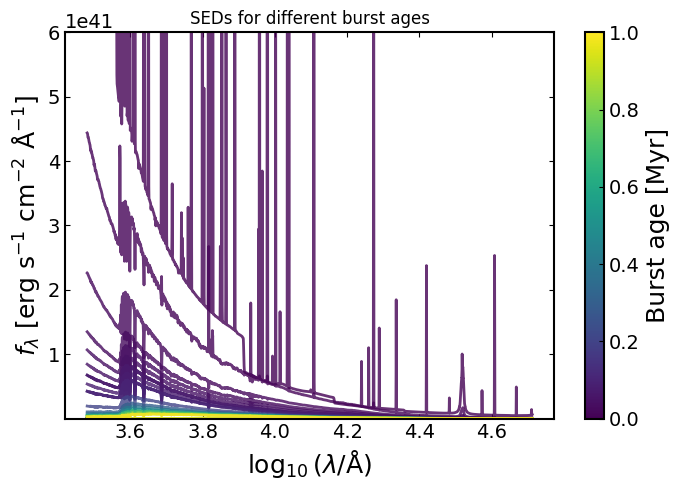

In [87]:
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

for t in years:
    print(t)

    burst = {
        "age": t,     # convert Myr → Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }
    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
       spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    ax.plot(
        np.log10(model.spec_wavs),  # log10(lambda / Å)
        model.spectrum,             # f_lambda [erg s^-1 cm^-2 Å^-1]
        color=cmap(norm(t)),
        alpha=0.8
    )

ax.set_xlabel(r"$\log_{10}(\lambda / \mathrm{\AA})$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_title("SEDs for different burst ages")
ax.set_ylim(bottom=1e37)
ax.set_ylim(top=6e41)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()

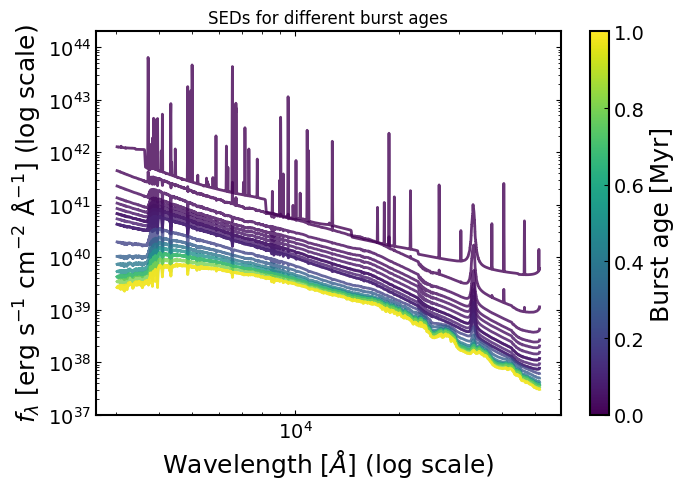

In [88]:
# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:

    burst = {
        "age": t,     # convert Myr → Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }
    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
       spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=1e37)
ax.set_ylim(top=2e44)


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


## investigating edge in 0 Myr Plot

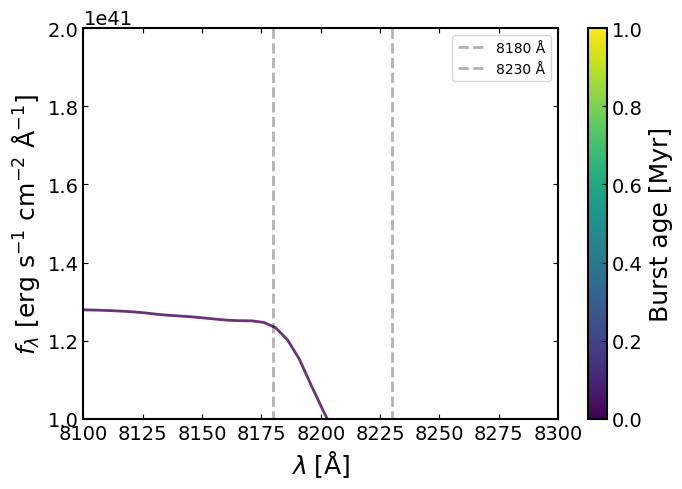

In [89]:
year = 0

fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())
burst = {
        "age": year / 1000,            # Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,     
        "veldisp": 200.
    }

model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

ax.plot(
        model.spec_wavs,      # linear wavelength
        model.spectrum,       # linear flux
        color=cmap(norm(year)),
        alpha=0.8
    )

wavelength1 = 8180
wavelength2 = 8230

ax.vlines(wavelength1, color = "black", linestyle="--", ymax=1e37, ymin=2e41, alpha=0.3, label= str(wavelength1) + " Å")
ax.vlines(wavelength2, color = "black", linestyle="--", ymax=1e37, ymin=2e41, alpha=0.3, label= str(wavelength2) + " Å")
ax.set_xlabel(r"$\lambda \; [\mathrm{\AA}]$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_ylim(1e41, 2e41)
ax.set_xlim(8100, 8300)
ax.legend()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()

## Balmer Edge Sanity Check

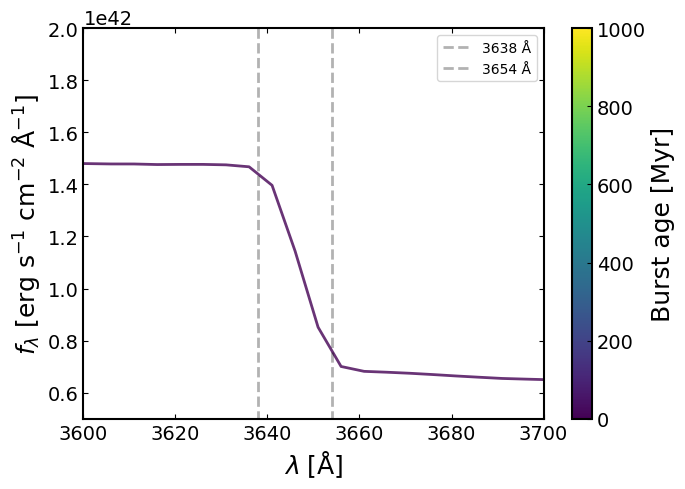

In [ ]:
year = 0

fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())
burst = {
        "age": year / 1000,            # Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,     
        "veldisp": 200.
    }

model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

ax.plot(
        model.spec_wavs,      # linear wavelength
        model.spectrum,       # linear flux
        color=cmap(norm(year)),
        alpha=0.8
    )

wavelength1 = 3638
wavelength2 = 3654


#ax.set_yscale('log')
ax.vlines(wavelength1, color = "black", linestyle="--", ymax=1e37, ymin=2e42, alpha=0.3, label= str(wavelength1) + " Å")
ax.vlines(wavelength2, color = "black", linestyle="--", ymax=1e37, ymin=2e42, alpha=0.3, label= str(wavelength2) + " Å")
ax.set_xlabel(r"$\lambda \; [\mathrm{\AA}]$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_ylim(5e41, 2e42)
ax.set_xlim(3600, 3700)
ax.legend()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()

# EW of lines with nebula emission

In [93]:
ages_myr_3 = np.arange(1,10,1)

years2_myr = np.concatenate([ages_myr_1, ages_myr_2, ages_myr_3])
print(years2_myr)

[   0   10   20   30   40   50   60   70   80   90  100  200  300  400
  500  600  700  800  900 1000    1    2    3    4    5    6    7    8
    9]


In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#spectral diagnostic functions
def equivalent_width(wave, flux, line_region, blue_cont, red_cont):

    line_mask = (wave > line_region[0]) & (wave < line_region[1])
    blue_mask = (wave > blue_cont[0]) & (wave < blue_cont[1])
    red_mask  = (wave > red_cont[0]) & (wave < red_cont[1])

    cont_flux = np.mean(
        np.concatenate([flux[blue_mask], flux[red_mask]])
    )

    ew = np.trapz(1 - flux[line_mask] / cont_flux,
                  wave[line_mask])

    return ew


def d4000(wave, flux):

    blue = (wave > 3850.) & (wave < 3950.)
    red  = (wave > 4000.) & (wave < 4100.)

    return np.mean(flux[red]) / np.mean(flux[blue])

#Line windows
HDELTA_LINE = (4083., 4122.)
HDELTA_BLUE = (4041., 4079.)
HDELTA_RED  = (4128., 4161.)

HALPHA_LINE = (6553., 6573.)
HALPHA_BLUE = (6500., 6540.)
HALPHA_RED  = (6575., 6620.)

OII_LINE = (3720., 3735.)
OII_BLUE = (3650., 3700.)
OII_RED  = (3740., 3800.)

ew_hdelta_vals = []
ew_halpha_vals = []
ew_oii_vals = []
d4000_vals = []


for t in years2_myr:

    burst = {
        "age": t/1000,            # Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,        # Gyr
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    wave = model.spectrum[:, 0]
    flux = model.spectrum[:, 1]

    ew_hdelta = equivalent_width(
        wave, flux,
        HDELTA_LINE,
        HDELTA_BLUE,
        HDELTA_RED
    )

    ew_halpha = equivalent_width(
        wave, flux,
        HALPHA_LINE,
        HALPHA_BLUE,
        HALPHA_RED
    )

    ew_oii = equivalent_width(
        wave, flux,
        OII_LINE,
        OII_BLUE,
        OII_RED
    )
    d4 = d4000(wave, flux)

    ew_hdelta_vals.append(ew_hdelta)
    ew_halpha_vals.append(ew_halpha)
    ew_oii_vals.append(ew_oii)
    d4000_vals.append(d4)

print("\nSpectral diagnostics:\n")
for i, t in enumerate(years2_myr):
    print(f"Age = {t:.0f} Myr")
    print(f"  EW(Hδ)  = {ew_hdelta_vals[i]:.2f} Å")
    print(f"  EW(Hα)  = {ew_halpha_vals[i]:.2f} Å")
    print(f"  EW([O II]) = {ew_oii_vals[i]:.2f} Å")
    print(f"  D4000   = {d4000_vals[i]:.2f}")
    print()

results_df = pd.DataFrame({
    "Age_Myr": years2_myr,
    "EW_Hdelta_A": ew_hdelta_vals,
    "EW_Halpha_A": ew_halpha_vals,
    "EW_OII_A": ew_oii_vals,
    "D4000": d4000_vals
})


Spectral diagnostics:

Age = 0 Myr
  EW(Hδ)  = -63.73 Å
  EW(Hα)  = -314.75 Å
  EW([O II]) = -868.87 Å
  D4000   = 0.49

Age = 10 Myr
  EW(Hδ)  = 3.67 Å
  EW(Hα)  = -14.00 Å
  EW([O II]) = -3.50 Å
  D4000   = 0.96

Age = 20 Myr
  EW(Hδ)  = 5.86 Å
  EW(Hα)  = 2.42 Å
  EW([O II]) = 0.39 Å
  D4000   = 0.97

Age = 30 Myr
  EW(Hδ)  = 6.91 Å
  EW(Hα)  = 2.65 Å
  EW([O II]) = 0.51 Å
  D4000   = 0.99

Age = 40 Myr
  EW(Hδ)  = 7.24 Å
  EW(Hα)  = 2.74 Å
  EW([O II]) = 0.54 Å
  D4000   = 1.00

Age = 50 Myr
  EW(Hδ)  = 7.52 Å
  EW(Hα)  = 2.84 Å
  EW([O II]) = 0.59 Å
  D4000   = 1.01

Age = 60 Myr
  EW(Hδ)  = 7.77 Å
  EW(Hα)  = 2.92 Å
  EW([O II]) = 0.62 Å
  D4000   = 1.02

Age = 70 Myr
  EW(Hδ)  = 7.77 Å
  EW(Hα)  = 2.92 Å
  EW([O II]) = 0.62 Å
  D4000   = 1.02

Age = 80 Myr
  EW(Hδ)  = 8.00 Å
  EW(Hα)  = 2.98 Å
  EW([O II]) = 0.65 Å
  D4000   = 1.03

Age = 90 Myr
  EW(Hδ)  = 8.05 Å
  EW(Hα)  = 2.98 Å
  EW([O II]) = 0.64 Å
  D4000   = 1.04

Age = 100 Myr
  EW(Hδ)  = 8.05 Å
  EW(Hα)  = 2.98 Å
  EW

D:\temp\ipykernel_4152\1963408120.py:43: RuntimeWarning: divide by zero encountered in log10
  log_age = np.log10(age_myr[mask])


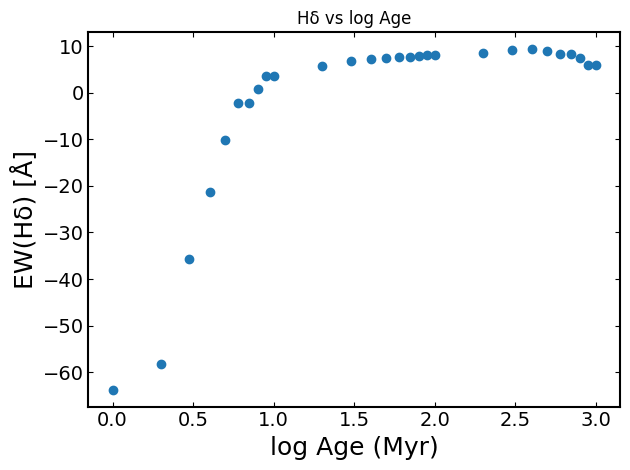

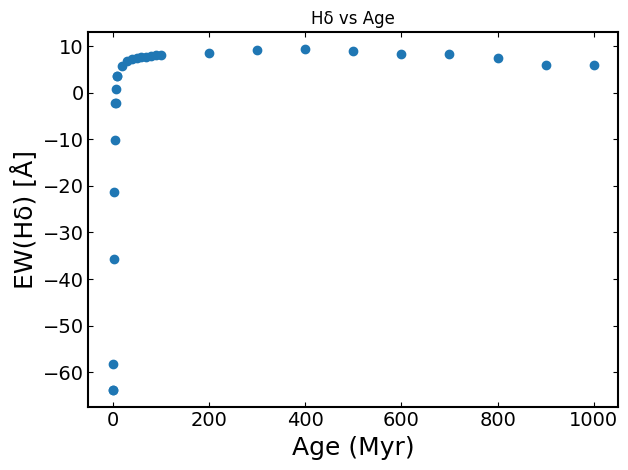

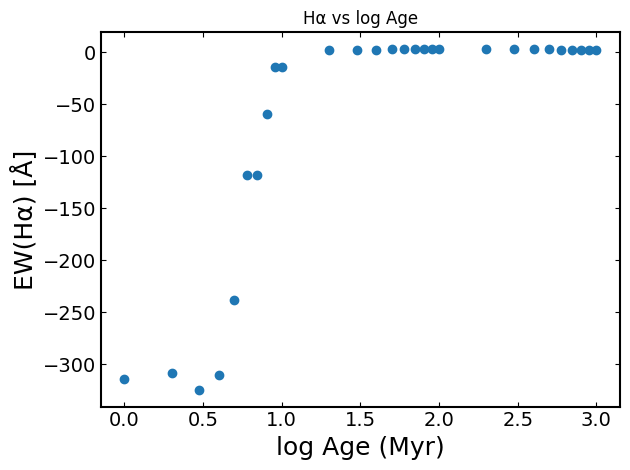

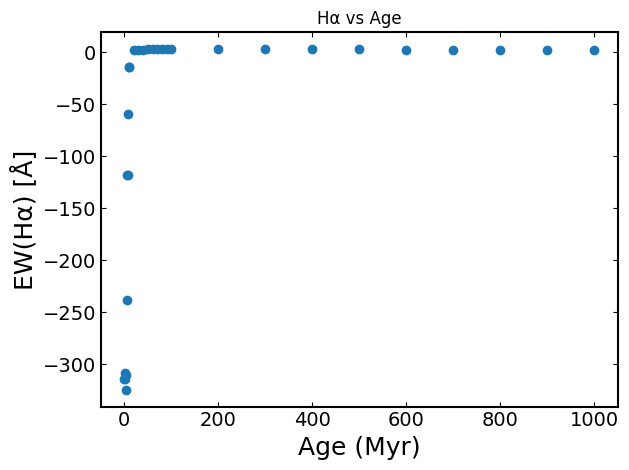

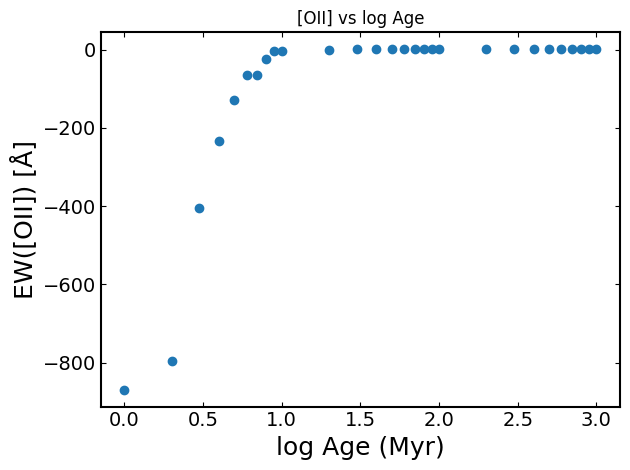

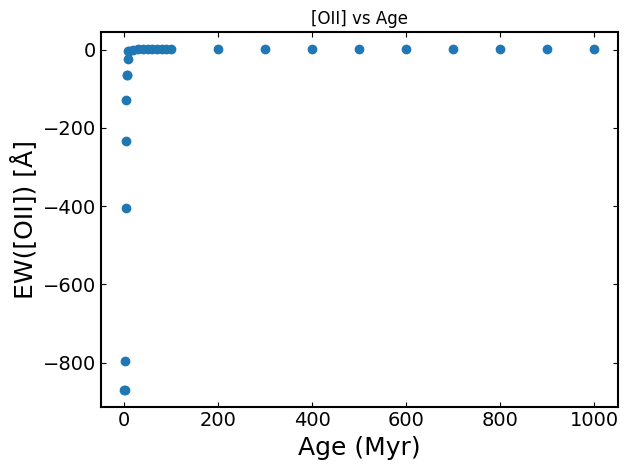

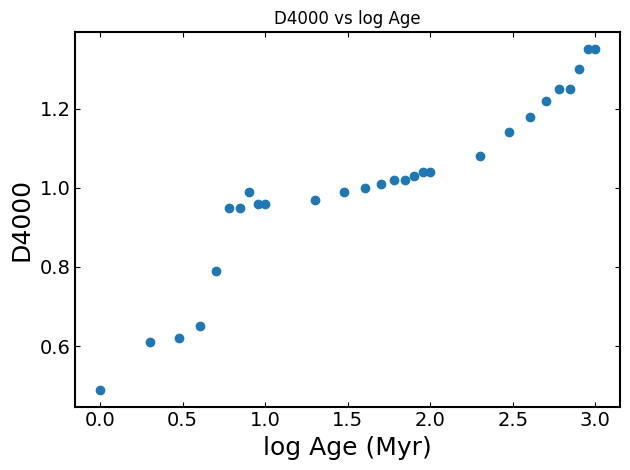

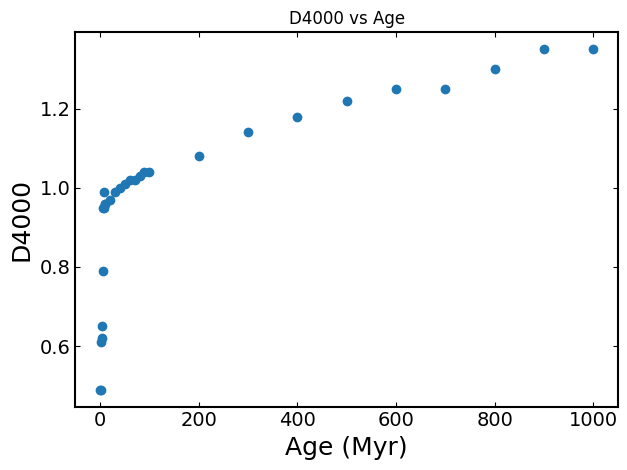

In [98]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np

# Ages in Myr
age_myr = np.array([
    0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    200, 300, 400, 500, 600, 700, 800, 900, 1000
])

# EW(Hδ)
ew_hdelta = np.array([
    -63.73, -63.73, -58.30, -35.76, -21.20, -10.07, -2.26, -2.26, 0.74, 3.67,
    3.67, 5.86, 6.91, 7.24, 7.52, 7.77, 7.77, 8.00, 8.05, 8.05,
    8.45, 9.16, 9.33, 8.93, 8.37, 8.37, 7.50, 5.90, 5.90
])

# EW(Hα)
ew_halpha = np.array([
    -314.75, -314.75, -308.80, -324.54, -310.42, -238.60, -118.31, -118.31, -59.64, -14.00,
    -14.00, 2.42, 2.65, 2.74, 2.84, 2.92, 2.92, 2.98, 2.98, 2.98,
    2.96, 2.96, 2.97, 2.87, 2.76, 2.76, 2.62, 2.39, 2.39
])

# EW([O II])
ew_oii = np.array([
    -868.87, -868.87, -797.05, -404.26, -233.27, -128.42, -65.16, -65.16, -24.00, -3.50,
    -3.50, 0.39, 0.51, 0.54, 0.59, 0.62, 0.62, 0.65, 0.64, 0.64,
    0.70, 0.79, 0.80, 0.78, 0.74, 0.74, 0.73, 0.72, 0.72
])

# D4000
d4000 = np.array([
    0.49, 0.49, 0.61, 0.62, 0.65, 0.79, 0.95, 0.95, 0.99, 0.96,
    0.96, 0.97, 0.99, 1.00, 1.01, 1.02, 1.02, 1.03, 1.04, 1.04,
    1.08, 1.14, 1.18, 1.22, 1.25, 1.25, 1.30, 1.35, 1.35
])


mask = age_myr >= 0
log_age = np.log10(age_myr[mask])

#Plot EW(Hδ)
plt.figure()
plt.scatter(log_age, ew_hdelta[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel("EW(Hδ) [Å]")
plt.title("Hδ vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], ew_hdelta[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel("EW(Hδ) [Å]")
plt.title("Hδ vs Age")
plt.tight_layout()
plt.show()

#Plot EW(Hα)
plt.figure()
plt.scatter(log_age, ew_halpha[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel("EW(Hα) [Å]")
plt.title("Hα vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], ew_halpha[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel("EW(Hα) [Å]")
plt.title("Hα vs Age")
plt.tight_layout()
plt.show()

#Plot EW([O II])
plt.figure()
plt.scatter(log_age, ew_oii[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel("EW([OII]) [Å]")
plt.title("[OII] vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], ew_oii[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel("EW([OII]) [Å]")
plt.title("[OII] vs Age")
plt.tight_layout()
plt.show()

#Plot D4000
plt.figure()
plt.scatter(log_age, d4000[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel("D4000")
plt.title("D4000 vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], d4000[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel("D4000")
plt.title("D4000 vs Age")
plt.tight_layout()
plt.show()

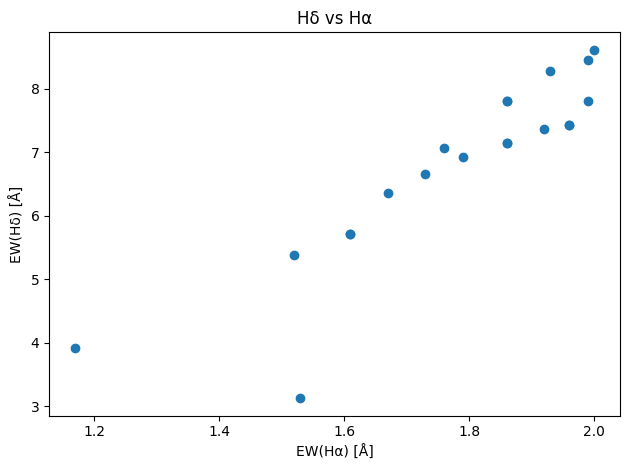

In [59]:

# --- Plot EW(Hδ) ---
plt.figure()
plt.scatter(ew_halpha[mask], ew_hdelta[mask], marker='o')
plt.xlabel("EW(Hα) [Å]")
plt.ylabel("EW(Hδ) [Å]")
plt.title("Hδ vs Hα")
plt.tight_layout()
plt.show()